# Projeto 10: Regressão venda de vídeo games


#### regressão, com previsão de valores
#### base de dados de vndas de jogos de vídeo games
#### agora vamos fazer a previsão de 3 valores no estudo de caso anterior. 

No linux:

### conda activate YouTube

### conda env list

conda environments:

base                     /home/fabiene/anaconda3

Maq2                     /home/fabiene/anaconda3/envs/Maq2

RBA_est                  /home/fabiene/anaconda3/envs/RBA_est

Robyn                    /home/fabiene/anaconda3/envs/Robyn

Udemy                    /home/fabiene/anaconda3/envs/Udemy

YouTube               *  /home/fabiene/anaconda3/envs/YouTube

pycaret-env              /home/fabiene/anaconda3/envs/pycaret-env



## Etapa 1: Importação das bibliotecas

In [1]:
import pandas as pd
import torch
from torch import nn, optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
torch.__version__

'2.8.0+cu128'

## Etapa 2: Base de dados

Sem torch.manual_seed:

Cada vez que treinamos a rede, os pesos iniciais mudam → os resultados podem variar.

Com torch.manual_seed(123):

Sempre começa com os mesmos pesos aleatórios → resultados reprodutíveis.

👉 Resumindo:
    
torch.manual_seed(123) serve para garantir reprodutibilidade dos experimentos no PyTorch.



In [2]:
torch.manual_seed(123)

In [3]:
# pré processamento
base = pd.read_csv('games.csv')

base.tail(5)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16718,Winning Post 8 2016,PSV,2016.0,Simulation,Tecmo Koei,0.00,0.00,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
base.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')


'Name' nome do jogo

'Platform' - plataforma (Wii, NES, GB (game boy)

'Year_of_Release', ano do lançamento do produto

Genre, gênero (sports, racing, platform, role-playing

'Publisher' , nintendo

'NA_Sales', vendas na América do Norte ( o que vamos prever)

'EU_Sales', vendas na Europa ( o que vamos prever)

'JP_Sales', vendas no japão ( o que vamos prever)

'Other_Sales', vendas em outros locais

'Global_Sales', venda global - soma geral das compras pelo mundo

'Critic_Score', nota que o jogo ganhou 

'Critic_Count', 

'User_Score', nota dos usuários deram ao jogo 

'User_Count', 
   
'Developer', desenvolvedor do jogo, exemplo nintendo
 
'Rating', relativo a nota

 

### Colocando o global sales estariamos enganando os algoritmos para fazer as previsões: 'NA_Sales', 'EU_Sales', 'JP_Sales'.

<b>Overfitting</b> → quando o modelo aprende demais os detalhes/ruídos do treino, mas não generaliza bem para novos dados.

O outro problema, quando os dados previsores já são tendenciosos ou problemáticos, tem a ver com <b>viés</b>:

===========================================


tipos de viés nos dados:

<b>Sampling bias</b> → quando a amostra não representa bem a população real.

<b>Measurement bias</b> → quando os dados foram coletados de forma distorcida.

<b>Historical bias</b> → quando os dados refletem desigualdades ou distorções históricas.

===========================================


Quando uma feature (variável preditora) já contém, de forma direta ou indireta, a resposta que queremos prever, isso tem um nome bem específico em machine learning: <b>Data leakage (ou vazamento de informação)</b>.

Por isso é retirado a coluna Global_Sales 


O que é <b>Data Leakage</b>

Acontece quando informações do futuro ou do alvo (label) “vazam” para as features.

O modelo acaba aprendendo algo que não teria disponível em produção.

Isso faz com que os resultados do treino/validação fiquem artificialmente bons, mas o modelo falha no mundo real.

✅ Exemplos:

Prever se uma transação é fraudulenta, mas usar como feature uma coluna que foi criada após a fraude ser detectada.

Prever preço de um imóvel usando uma coluna que já contém o valor de venda final.

Prever se um paciente terá uma doença usando um exame feito depois do diagnóstico.


In [5]:
base.shape

(16719, 16)

In [6]:
# limpeza dos dados
# axis =1, apaga a coluna, já no axis=0 apagaria a linha
base = base.drop('Other_Sales', axis = 1)
base = base.drop('Global_Sales', axis = 1) # evitar data leakage
base = base.drop('Developer', axis = 1) # coluna repetida

In [7]:
# atualização do shape
base.shape

(16719, 13)

# verificar os dados faltantes

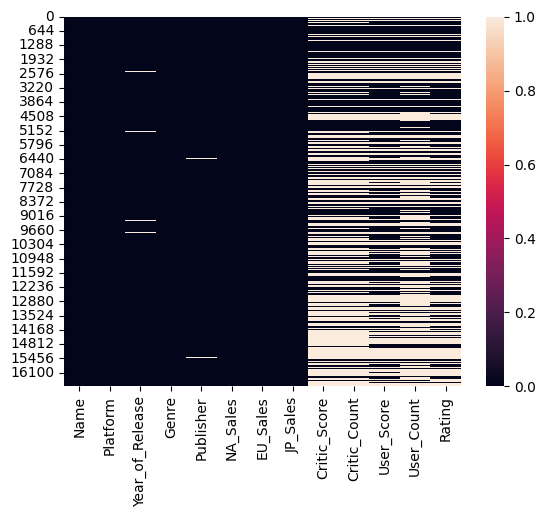

In [8]:
sns.heatmap(base.isnull());

In [9]:
len(base)

16719

In [10]:
base.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Rating             6769
dtype: int64

In [11]:
# muitos valores faltantes são os Critic_Score, Critic_Count, User_Score, User_Count e User_Count.

In [12]:
#excluir o registro da linha que tem dados zerados

#deleta toda a linha axis = 0

base = base.dropna(axis = 0)      


In [13]:
len(base)

6825

In [14]:
base.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Rating             0
dtype: int64

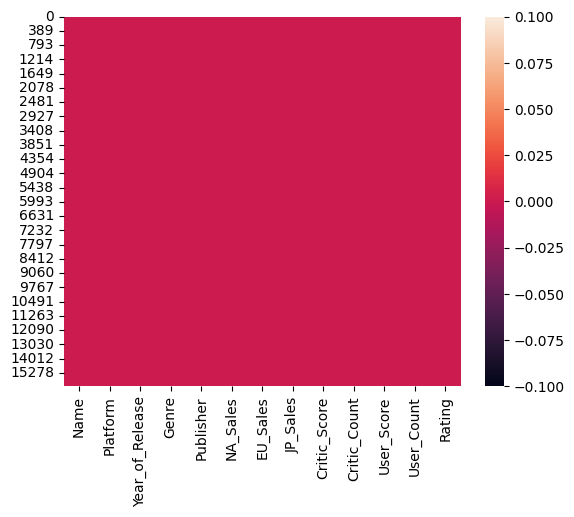

In [15]:
sns.heatmap(base.isnull()); # interessante é não ter valores nulos. 

In [16]:
# novo shape analisado
base.shape

(6825, 13)

In [17]:
# faremos o tratamento dos dados, pois há dados inconsistentes 

# a ideia é ter mais de 1 registro de vendas, maior que 1 ficou em apenas 584 registros
base.loc[base['NA_Sales'] > 1]

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,76.0,51.0,8,322.0,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,82.0,73.0,8.3,709.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,80.0,73.0,8,192.0,E
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,89.0,65.0,8.5,431.0,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,58.0,41.0,6.6,129.0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872,NCAA Football 14,X360,2013.0,Sports,Electronic Arts,1.01,0.00,0.00,77.0,18.0,5.8,74.0,E
1877,NFL 2K1,DC,2000.0,Sports,Sega,1.02,0.05,0.00,97.0,22.0,6,47.0,E
1881,Madden NFL 2004,XB,2003.0,Sports,Electronic Arts,1.02,0.02,0.00,92.0,27.0,8.3,48.0,E
1889,NCAA Football 13,X360,2012.0,Action,Electronic Arts,1.02,0.00,0.00,76.0,20.0,5.5,65.0,E


In [18]:
base = base.loc[base['NA_Sales'] > 1]
base.shape

(584, 13)

In [19]:
base.loc[base['EU_Sales'] > 1] # fazendo o mesmo critério para vendas na Europa, e os dados caem mais

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,76.0,51.0,8,322.0,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,82.0,73.0,8.3,709.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,80.0,73.0,8,192.0,E
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,89.0,65.0,8.5,431.0,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,58.0,41.0,6.6,129.0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...
568,Medal of Honor,PS,1998.0,Shooter,Electronic Arts,1.44,1.09,0.00,92.0,17.0,8.6,80.0,T
573,Tom Clancy's Splinter Cell,PS2,2003.0,Action,Ubisoft,1.15,1.11,0.00,89.0,24.0,7.7,102.0,T
591,Mario Strikers Charged,Wii,2007.0,Sports,Nintendo,1.05,1.05,0.24,79.0,47.0,8,124.0,E10+
610,Crazy Taxi,PS2,2001.0,Racing,Acclaim Entertainment,1.13,1.12,0.06,80.0,15.0,7.9,46.0,T


In [20]:
base = base.loc[base['EU_Sales'] > 1]
base.shape

(258, 13)

In [21]:
len(base.loc[base['JP_Sales'] > 1])

47

In [22]:
# avaliar o nome do jogo, e sua quantidade de vezes que o nome aparece
base['Name'].value_counts

<bound method IndexOpsMixin.value_counts of 0                      Wii Sports
2                  Mario Kart Wii
3               Wii Sports Resort
6           New Super Mario Bros.
7                        Wii Play
                  ...            
568                Medal of Honor
573    Tom Clancy's Splinter Cell
591        Mario Strikers Charged
610                    Crazy Taxi
636         The Sims: Bustin' Out
Name: Name, Length: 258, dtype: object>

In [23]:
import pandas as pd

# Contagem de valores
contagem = base['Name'].value_counts()

# Transformando em DataFrame
df_contagem = contagem.reset_index()

# Renomeando as colunas
df_contagem.columns = ['Name', 'Count']

display(df_contagem.sort_values(by='Count', ascending = True))

df_contagem.sort_values(by='Count', ascending = False)

,Name,Count
111,Spider-Man 2,1
141,The Legend of Zelda: Twilight Princess,1
142,Crash Bandicoot 3: Warped,1
143,Mario Kart 8,1
144,Super Smash Bros. Melee,1
...,...,...
4,The Elder Scrolls V: Skyrim,3
3,Battlefield 4,3
2,Call of Duty: Ghosts,3
1,Assassin's Creed IV: Black Flag,3


,Name,Count
0,Grand Theft Auto V,4
2,Call of Duty: Ghosts,3
3,Battlefield 4,3
4,The Elder Scrolls V: Skyrim,3
1,Assassin's Creed IV: Black Flag,3
...,...,...
94,Mario Strikers Charged,1
95,Crazy Taxi,1
96,Sonic Rush,1
97,Spider-Man,1


In [24]:
df_contagem['Count'].unique() # poucas vezes

array([4, 3, 2, 1])

In [25]:
# ideia é apagar o nome do jogo, Pois temos outros nomes, platform, genre (gênero) e a (produtora) Publisher


In [26]:
# apagar toda a coluna
base = base.drop('Name', axis = 1)

In [27]:
# novo shape para analise
base.shape


(258, 12)

In [28]:
# lista das colunas para previsão
colunas_previsao = list(base.columns[[0, 1, 2, 3, 7, 8, 9, 10, 11]])
print(colunas_previsao)

['Platform', 'Year_of_Release', 'Genre', 'Publisher', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Rating']


In [29]:
coluna_vendas = list(base.columns[4:7])
coluna_vendas

['NA_Sales', 'EU_Sales', 'JP_Sales']

In [30]:
previsores = base.iloc[:, [0, 1, 2, 3, 7, 8, 9, 10, 11]].values
vendas = base.iloc[:, 4:7].values

In [31]:
previsores

array([['Wii', 2006.0, 'Sports', ..., '8', 322.0, 'E'],
       ['Wii', 2008.0, 'Racing', ..., '8.3', 709.0, 'E'],
       ['Wii', 2009.0, 'Sports', ..., '8', 192.0, 'E'],
       ...,
       ['Wii', 2007.0, 'Sports', ..., '8', 124.0, 'E10+'],
       ['PS2', 2001.0, 'Racing', ..., '7.9', 46.0, 'T'],
       ['PS2', 2003.0, 'Simulation', ..., '8.4', 42.0, 'T']], dtype=object)

In [32]:
vendas[:5]

array([[41.36, 28.96,  3.77],
       [15.68, 12.76,  3.79],
       [15.61, 10.93,  3.28],
       [11.28,  9.14,  6.5 ],
       [13.96,  9.18,  2.93]])

In [33]:
# usar o OneHotEncoder, operação OneHot, pois temos dados categóricos, ou em string, nomes

In [34]:
base['Platform'].unique()

array(['Wii', 'DS', 'X360', 'PS3', 'PS2', '3DS', 'PS4', 'PS', 'XB', 'PSP',
       'WiiU', 'GC', 'GBA', 'XOne', 'PC'], dtype=object)

In [35]:
# colunas novas com base a quantidade de valores de cada atributo, abaixo é só se tivesse 2 tipos de dados na coluna platform
# Wii 1 0
# PS2 0 1

# usaremos o OneHotEncoder

In [36]:
# onde será aplicado o OneHot
list(base.columns[[0]])

['Platform']

In [37]:
n=2
print(list(base.columns[[n]]))
base[f'{list(base.columns[[n]])[0]}'].unique()

['Genre']


array(['Sports', 'Racing', 'Platform', 'Misc', 'Action', 'Puzzle',
       'Shooter', 'Fighting', 'Simulation', 'Role-Playing', 'Adventure',
       'Strategy'], dtype=object)

In [38]:
n=3
print(list(base.columns[[n]]))
base[f'{list(base.columns[[n]])[0]}'].unique()

['Publisher']


array(['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive',
       'Sony Computer Entertainment', 'Activision', 'Ubisoft',
       'Bethesda Softworks', 'Electronic Arts', 'SquareSoft',
       'GT Interactive', 'Konami Digital Entertainment',
       'Sony Computer Entertainment Europe', 'Virgin Interactive',
       'LucasArts', '505 Games', 'Warner Bros. Interactive Entertainment',
       'Universal Interactive', 'Square Enix', 'Capcom', 'Atari',
       'Eidos Interactive', 'Namco Bandai Games', 'Sega', 'THQ',
       'Acclaim Entertainment'], dtype=object)

In [39]:
n=8  # não usar esse no OneHotEncoder
print(list(base.columns[[n]]))
base[f'{list(base.columns[[n]])[0]}'].unique()

['Critic_Count']


array([ 51.,  73.,  65.,  41.,  80.,  64.,  63.,  45.,  33.,  50.,  58.,
        62.,  37.,  54.,  81.,  89.,  21., 100.,  39.,  56.,  66.,  57.,
        86.,  16.,  82.,  67.,  29.,  15.,  70.,  99.,  20.,  87.,  23.,
        24.,  10.,  27.,  42.,  91.,  53.,  46.,  84.,  38.,  12.,  90.,
        97.,  44., 105.,  77.,  68.,  28.,  94.,  96.,  61.,  22.,  88.,
        98.,  85.,  13.,   8.,  95.,  17.,  35.,  19.,  14., 113.,  83.,
        72.,  48.,  30.,  76.,  18.,  34.,  40., 101.,   9.,  32.,  78.,
        36.,  74.,  25.,  75.,  59.,  31.,  79.,  49.,  60.,  11.,  43.,
       107.,  52.,  47.,  26.])

In [40]:
n=11
print(list(base.columns[[n]]))
base[f'{list(base.columns[[n]])[0]}'].unique()

['Rating']


array(['E', 'M', 'T', 'E10+'], dtype=object)

In [41]:
#[0, 1, 2, 3, 7, 8, 9, 10, 11]
#[0, 1, 2, 3, 4, 5, 6, 7, 8] # o 11 agora é coluna 8
 # novo previsores

In [42]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [0, 2, 3, 8])], remainder='passthrough')  
# colunas que desejamos alterar para onehot => [0, 2, 3, 8]
previsores = onehotencorder.fit_transform(previsores).toarray()

In [43]:
previsores

array([[  0. ,   0. ,   0. , ...,  51. ,   8. , 322. ],
       [  0. ,   0. ,   0. , ...,  73. ,   8.3, 709. ],
       [  0. ,   0. ,   0. , ...,  73. ,   8. , 192. ],
       ...,
       [  0. ,   0. ,   0. , ...,  47. ,   8. , 124. ],
       [  0. ,   0. ,   0. , ...,  15. ,   7.9,  46. ],
       [  0. ,   0. ,   0. , ...,  26. ,   8.4,  42. ]])

## Etapa 3: Construção do modelo

In [44]:
previsores.shape

(258, 61)

In [45]:
print(f'Camada de entrada das features: {previsores.shape[1]}')

print(f'Camada de saída: {vendas.shape[1]}')


Camada de entrada das features: 61
Camada de saída: 3


In [46]:
neuronio_camada_oculta = (previsores.shape[1] + vendas.shape[1])/2

print(f'Cálculo dos neurônios das camadas ocultas {neuronio_camada_oculta}')

Cálculo dos neurônios das camadas ocultas 32.0


In [47]:
# 61 -> 32 -> 32 -> 3
# 61 → número de entradas (features do seu dataset).
# 32 → 32 → camadas ocultas com 32 neurônios cada.
# 3 → número de saídas (pode ser 3 classes para classificação ou 3 valores para regressão multivariada).

#nn.Module → classe base de qualquer modelo neural no PyTorch.
#nn.Linear(in_features, out_features) → camada totalmente conectada (densa), faz:

# 𝑦=𝑋⋅𝑊+𝑏
#onde W são os pesos e b o bias.

class regressor_torch(nn.Module):
    def __init__(self):
        super().__init__()
        # definiçãop dos atributos
        self.dense0 = nn.Linear(61, 32) #→ transforma os 61 inputs em 32 neurônios.
        self.dense1 = nn.Linear(32, 32) # → conecta 32 neurônios em mais 32 neurônios.
        self.activation = nn.Sigmoid() # sigmoid, entra valores entre 0 e 1 | → função de ativação que comprime a saída para o intervalo (0, 1).
        self.output = nn.Linear(32, 3) #→ transforma os 32 neurônios finais em 3 saídas.

    def forward(self, X):
        # ligação das redes neurais -> fluxo da rede neural
        X = self.dense0(X)   # aplica camada 61 -> 32
        X = self.activation(X) # aplica Sigmoid
        X = self.dense1(X)    # aplica camada 32 -> 32
        X = self.activation(X)  # aplica Sigmoid
        X = self.output(X)     # aplica camada final 32 -> 3
        # retornar a rede neural acoplada
        return X

O método forward descreve como os dados fluem pela rede:

1 - Input de 61 features → camada dense0 → vira um vetor de tamanho 32.

2 - Passa pela Sigmoid.

3- Vai para dense1 → continua com 32.

4 - Outra Sigmoid.

5 - Camada final output → gera 3 valores.

O que sai de return X é o resultado do modelo (a previsão).

<b>Ativação</b>: Além da <b>Sigmoid</b>, podemos usar várias, dependendo do problema:

1- <b>nn.ReLU()</b> → mais usada hoje em dia, rápida e evita saturação.

2- <b>nn.Tanh()</b> → outputs entre -1 e 1.

3- <b>nn.Softmax(dim=1)</b> → usado na camada de saída em classificação multiclasse.

4- <b>nn.Identity()</b> → nenhuma ativação (puro linear), útil em regressão.

Além da camada densa <b>(nn.Linear)</b>, o PyTorch oferece várias outras camadas para diferentes tipos de redes neurais. Abaixo está a lista as principais (resumido e direto):

### 🔹 1. Camadas Lineares (Fully Connected)

<b>nn.Linear(in_features, out_features)</b> → já vimos, conecta todos os neurônios de entrada a todos os de saída.

### 🔹 2. Camadas Convolucionais (para imagens, séries temporais, etc.)

<b>nn.Conv1d(in_channels, out_channels, kernel_size)</b> → convolução 1D (ex.: séries temporais).

<b>nn.Conv2d(in_channels, out_channels, kernel_size)</b> → convolução 2D (ex.: imagens).

<b>nn.Conv3d(...)</b> → para volumes (ex.: vídeos, dados médicos 3D).

Essas camadas aprendem filtros que detectam padrões (bordas, tendências, etc.).

### 🔹 3. Camadas Recurrentes (para sequência/temporal)

<b>nn.RNN(input_size, hidden_size)</b> → rede recorrente simples.

<b>nn.LSTM(input_size, hidden_size)</b> → usa Long Short-Term Memory (melhor para dependências longas).

<b>nn.GRU(input_size, hidden_size)</b> → variante mais leve que o LSTM.

Perfeitas para previsão de séries temporais, NLP e dados sequenciais.

### 🔹 4. Camadas de Normalização

<b>nn.BatchNorm1d(num_features)</b> → normaliza lotes de dados em 1D.

<b>nn.BatchNorm2d(num_features)</b> → para imagens.

<b>nn.LayerNorm(normalized_shape)</b> → normalização por camada.

Usadas para estabilizar e acelerar o treino.

### 🔹 5. Camadas de Dropout (regularização)

<b>nn.Dropout(p=0.5)</b> → zera aleatoriamente alguns neurônios durante o treino.

Ajuda a evitar overfitting.

### 🔹 6. Camadas de Pooling (reduzir dimensão em CNNs)

<b>nn.MaxPool1d(kernel_size)</b>

<b>nn.MaxPool2d(kernel_size)</b>

<b>nn.AvgPool2d(kernel_size)</b>

Reduzem a resolução mas mantêm as informações principais.

### 🔹 7. Camadas de Embedding

<b>nn.Embedding(num_embeddings, embedding_dim)</b>

Transforma índices (categorias, palavras) em vetores densos.
Muito usado em NLP e variáveis categóricas.

### 🔹 8. Camadas Especiais

<b>nn.Softmax(dim)</b> → normaliza saídas para probabilidades.

<b>nn.Sigmoid()</b> → ativações.

<b>nn.Tanh()</b> → ativações.

nn.Identity() → camada que não faz nada (útil para testes ou remover ativação).



==============================================================

Resumo prático:

- <b>Tabular (dados de vendas, previsão, etc.)</b> → nn.Linear, possivelmente nn.BatchNorm, nn.Dropout.

- <b>Imagens</b> → nn.Conv2d + nn.MaxPool2d + nn.Linear.

- <b>Séries temporais</b> → nn.LSTM / nn.GRU ou nn.Conv1d.

- <b>Texto / categorias</b> → nn.Embedding.

==============================================================



$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

# 🔹 O ReLU (Rectified Linear Unit)

Características:

Simples, rápido de calcular.

Resolve o problema do vanishing gradient (quando os gradientes ficam quase zero em sigmoides/tanh).

Muito usado em camadas ocultas.

⚠️ Problema: pode causar “neurônios mortos” (quando muitos valores ficam ≤ 0 e nunca mais reativam).


# 🔹 1. Sigmoid

Saída entre 0 e 1 → ideal para classificação binária.

Problema: saturação → gradientes muito pequenos para valores extremos.

# 🔹 2. Tanh (Tangente Hiperbólica)

Saída entre -1 e 1.

Centraliza os dados em torno de 0 (melhor que sigmoid).

Mas ainda sofre com vanishing gradient.

# 🔹 3. Leaky ReLU

Variante do ReLU que deixa um “vazamento” para valores negativos.

Resolve o problema de neurônios mortos.

# 🔹 4. ELU (Exponential Linear Unit)

Parecido com ReLU, mas valores negativos seguem uma curva exponencial suave.
Melhora a aprendizagem, mas é mais caro computacionalmente.

# 🔹 5. Softmax

Transforma um vetor de valores em probabilidades que somam 1.

Usado em classificação multiclasse (saída com várias categorias).



🔹 Resumo, o uso mais comum:

Camadas ocultas → ReLU, Leaky ReLU, às vezes Tanh/ELU.

Saída binária → Sigmoid.

Saída multiclasse → Softmax.

In [48]:
# receber o objeto da classificação

regressor = regressor_torch()

In [49]:
regressor

regressor_torch(
  (dense0): Linear(in_features=61, out_features=32, bias=True)
  (dense1): Linear(in_features=32, out_features=32, bias=True)
  (activation): Sigmoid()
  (output): Linear(in_features=32, out_features=3, bias=True)
)

In [50]:
criterion = nn.MSELoss()  # critério de erro
optimizer = optim.Adam(regressor.parameters())

In [51]:
type(previsores) # ideia é transformar numpy em tensor

numpy.ndarray

🔹 criterion = nn.MSELoss()

#### função de perda (loss function).

nn.MSELoss() significa Erro Quadrático Médio (Mean Squared Error).

Isso mede a diferença entre o valor previsto pela rede (y_pred) e o valor real (y_true):

$\[
\text{MSE}(\hat{y}, y) \;=\; \frac{1}{N} \sum_{i=1}^{N} \left( \hat{y}_i - y_i \right)^2
\]
$

É muito usado em regressão (ex.: previsão de vendas, preços, séries temporais).

Quanto menor o loss, mais próxima a rede está dos valores reais.

================================

🔹 optimizer = optim.Adam(regressor.parameters())

definindo o otimizador.O Adam é um dos otimizadores mais usados, porque:

Ajusta automaticamente a taxa de aprendizado (learning rate).

Combina ideias do Momentum e do RMSProp.

Geralmente converge mais rápido do que o SGD puro.

regressor.parameters() → diz ao Adam quais pesos e biases da rede ele deve atualizar durante o treinamento.

### criterion → mede o quanto a rede errou.

### optimizer → decide como ajustar os pesos para errar menos na próxima rodada.

====================================================================

#### 🔹 Função de perda (MSE)


$ \[
\text{MSE}(\hat{y}, y) \;=\; \frac{1}{N} \sum_{i=1}^{N} \left( \hat{y}_i - y_i \right)^2
\]
$

$\hat{𝑦}_𝑖 $	 → valor previsto pela rede (output).

$𝑦_𝑖$ → valor real (target).



𝑁 → número de amostras no batch.

### 🔹 Gradiente (backpropagation)

O PyTorch calcula isso automaticamente, mas matematicamente o gradiente da MSE em relação à predição é:

$
\[
\frac{\partial \text{MSE}}{\partial \hat{y}_i} = \frac{2}{N} \left( \hat{y}_i - y_i \right)
\]
$

### 🔹 Atualização dos pesos (Adam Optimizer)

O Adam combina momentum e RMSProp. Para cada peso 

1 - Gradiente do passo t:

$
\[
g_t = \nabla_w \; \text{MSE}(w_t)
\]
$

2 - Momentos:

$
\[
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
\]$

$\[
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
\]
$

3 - Correção de viés:

$
\[
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad 
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
\]
$


4 - Atualização dos pesos:

$
\[
w_{t+1} = w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\]
$

𝜂→ taxa de aprendizado (learning rate).

$𝛽_1$, $𝛽_2$ → parâmetros do Adam (valores típicos: 0.9 e 0.999).

ϵ → valor pequeno para evitar divisão por zero.



In [52]:
previsores = torch.tensor(previsores, dtype=torch.float)
vendas = torch.tensor(vendas, dtype=torch.float)

In [53]:
previsores

tensor([[  0.0000,   0.0000,   0.0000,  ...,  51.0000,   8.0000, 322.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  73.0000,   8.3000, 709.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  73.0000,   8.0000, 192.0000],
        ...,
        [  0.0000,   0.0000,   0.0000,  ...,  47.0000,   8.0000, 124.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  15.0000,   7.9000,  46.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  26.0000,   8.4000,  42.0000]])

In [54]:
vendas[:5]

tensor([[41.3600, 28.9600,  3.7700],
        [15.6800, 12.7600,  3.7900],
        [15.6100, 10.9300,  3.2800],
        [11.2800,  9.1400,  6.5000],
        [13.9600,  9.1800,  2.9300]])

In [55]:
type(previsores)

torch.Tensor

In [56]:
dataset = torch.utils.data.TensorDataset(previsores, vendas)
# para o treinamento
train_loader = torch.utils.data.DataLoader(dataset, batch_size = 10, shuffle = True)
# treinamento batch_size que vai de 10 em 10 dados
# shuffle que mistura os dados


Cria um dataset PyTorch a partir dos tensores:

'dataset = torch.utils.data.TensorDataset(previsores, vendas)'

previsores: features (entradas).

vendas: labels/targets (saídas).

Ele "empacota" as duas coisas juntas, de modo que, quando você acessa um índice, você recebe um par (X, y).

In [57]:
X, y = dataset[0]
print(X)  # primeira linha das features
print(y)  # primeira linha do alvo

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0060e+03, 7.6000e+01, 5.1000e+01, 8.0000e+00,
        3.2200e+02])
tensor([41.3600, 28.9600,  3.7700])


DataLoader

'train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)'

Transforma o dataset em batches (lotes de dados).

batch_size=10 → cada iteração do treino vai pegar 10 amostras de uma vez (ao invés de 1 por 1).

shuffle=True → a cada epoch, os dados são embaralhados, para evitar que a rede aprenda padrões só pela ordem.

## Etapa 4: Treinamento do modelo

In [58]:
# verificar se temos a cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [59]:
# linkamos o nosso processo na cpu
regressor.to(device)

regressor_torch(
  (dense0): Linear(in_features=61, out_features=32, bias=True)
  (dense1): Linear(in_features=32, out_features=32, bias=True)
  (activation): Sigmoid()
  (output): Linear(in_features=32, out_features=3, bias=True)
)

In [60]:
for epoch in range(2000):
    # teremos que calcular o MSE para 3 processos, NA_sales, EU_sales e JP_sales
    running_loss = 0.
    running_mse_0 = 0. 
    running_mse_1 = 0.
    running_mse_2 = 0.

    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # enviado os dados para a cpu
        
        #Antes do backward, precisa zerar os gradientes acumulados da epoch anterior, senão eles se somariam.
        # zera o gradiente, para não acumular o processo
        optimizer.zero_grad()
        # prever os registros, com o batch_size de 10 registros 
        outputs = regressor(inputs)

        # calcular o mse para cada uma das variáveis:
        # todos os registros, com a coluna 0, depois coluna 1 e coluna 2
        # comparam as previsões das redes neurais (outputs), com os dados reais (labels)
        mse_0 = F.mse_loss(outputs[:,0], labels[:,0]).item()
        mse_1 = F.mse_loss(outputs[:,1], labels[:,1]).item()
        mse_2 = F.mse_loss(outputs[:,2], labels[:,2]).item()

          
        # acumular os resultados 
        running_mse_0 += mse_0 * len(inputs) # mse multiplado com os números de batch_size 10 (acumular os erros em cada instância, de cada variável)
        running_mse_1 += mse_1 * len(inputs)
        running_mse_2 += mse_2 * len(inputs)

        loss = criterion(outputs, labels) # treinamento da rede neural, valor total (cálculo do erro geral)
        loss.backward() # atualização dos pesos)

        optimizer.step() 
        # criar a variável loss, para ter o valor do erro. 

        loss = loss.item()
        running_loss += loss * len(inputs)

        print('\rÉpoca {:4d} - Loop {:3d} de {:3d}: erro_0 {:6.4f} | erro_1 {:6.4f} | erro_2 {:6.4f} - custo {:6.4f}'.format(epoch + 1,
                      i + 1,
                      len(train_loader),
                      mse_0,
                      mse_1,
                      mse_2,
                      loss), end = '\r')

    print('ÉPOCA {:4d} finalizada: erro_0 {:6.4f} | erro_1 {:6.4f} | erro_2 {:6.4f} - custo {:6.4f}         '.format(epoch + 1,
         running_mse_0/len(dataset),
         running_mse_1/len(dataset),
         running_mse_2/len(dataset),
         running_loss/len(dataset)))

ÉPOCA    1 finalizada: erro_0 21.8178 | erro_1 13.7230 | erro_2 1.3285 - custo 12.2898         
ÉPOCA    2 finalizada: erro_0 18.2655 | erro_1 10.4217 | erro_2 1.1840 - custo 9.9571         
ÉPOCA    3 finalizada: erro_0 15.5166 | erro_1 8.2907 | erro_2 1.1737 - custo 8.3270         7
ÉPOCA    4 finalizada: erro_0 13.6868 | erro_1 6.9916 | erro_2 1.1744 - custo 7.2843         6
ÉPOCA    5 finalizada: erro_0 12.7259 | erro_1 6.3374 | erro_2 1.1725 - custo 6.7453         8
ÉPOCA    6 finalizada: erro_0 12.2527 | erro_1 6.0233 | erro_2 1.1762 - custo 6.4841         7
ÉPOCA    7 finalizada: erro_0 12.0585 | erro_1 5.9109 | erro_2 1.1721 - custo 6.3805         9
ÉPOCA    8 finalizada: erro_0 11.9757 | erro_1 5.8674 | erro_2 1.1703 - custo 6.3378         1
ÉPOCA    9 finalizada: erro_0 11.9576 | erro_1 5.8557 | erro_2 1.1777 - custo 6.3304         8
ÉPOCA   10 finalizada: erro_0 11.9361 | erro_1 5.8516 | erro_2 1.1754 - custo 6.3210         4
ÉPOCA   11 finalizada: erro_0 11.9382 | erro_1 5.

## Etapa 5: Avaliação do modelo

In [61]:
regressor.eval()

regressor_torch(
  (dense0): Linear(in_features=61, out_features=32, bias=True)
  (dense1): Linear(in_features=32, out_features=32, bias=True)
  (activation): Sigmoid()
  (output): Linear(in_features=32, out_features=3, bias=True)
)

In [62]:
device

'cpu'

In [70]:
previsores = previsores.to(device)
# fazer a previsão
previsoes = regressor.forward(previsores)

In [71]:
# # variável previsoes que vai receber o regressor com a função forward, passando os previsores
# prevendo as 3 colunas NA_sales, EU_sales e JP_sales
previsoes

tensor([[7.5967, 4.6138, 1.6885],
        [4.2000, 2.7775, 0.6456],
        [7.5982, 4.6147, 1.6889],
        [4.2000, 2.7775, 0.6456],
        [7.5982, 4.6147, 1.6889],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [7.5982, 4.6147, 1.6889],
        [7.5982, 4.6147, 1.6889],
        [2.5558, 1.9592, 0.4938],
        [4.2000, 2.7775, 0.6456],
        [7.5561, 4.5922, 1.6798],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [2.3024, 1.8244, 0.4282],
        [7.5911, 4.6108, 1.6869],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [4.2000, 2.7775, 0.6456],
        [7.4760, 4.5494, 1.6624],
        [4.2000, 2.7775, 0.6456],
        [4.200

In [72]:
# para fazer previsão de mais 3 variáveis e usar o out_features=3, com o valor de 3, que é a quantidades de colunas que queremos prever. 

In [73]:
# comando para tirar a dimensão de tensores, para se tornar array e fazermos os cálculos
previsoes = previsoes.cpu().detach().numpy() # cpu para o processo que foi feito no device

In [74]:
previsoes

array([[7.5966554 , 4.6138325 , 1.6884695 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [7.5981984 , 4.61466   , 1.6889157 ],
       [4.2000446 , 2.7775307 , 0.64564234],
       [7.5981927 , 4.6146564 , 1.6889143 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.1999884 , 2.7775    , 0.6456234 ],
       [7.5981984 , 4.6146593 , 1.6889157 ],
       [7.5981984 , 4.61466   , 1.6889157 ],
       [2.555808  , 1.9591684 , 0.4937588 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [7.5560803 , 4.5921583 , 1.6797824 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [2.3023705 , 1.8244416 , 0.42822397],
       [7.59106   , 4.6108365 , 1.6869104 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.199965  , 2.7774873 , 0.64561915],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.199988  , 2.7774997 , 0.6456232 ],
       [4.

In [80]:
# quero fazer a média linha por linha e em todas as colunas (axis = 0) # correto
# ou seja, a média no NA_sales, EU_Sales e JP_sales
previsoes.mean(axis = 0)

array([3.7176464, 2.5444143, 0.6418265], dtype=float32)

axis = 0 (Horizontal): O cálculo da média é feito verticalmente, linha por linha. Como "colapsar as linhas" para obter um único valor de média por coluna.

In [78]:
len(previsoes)

258

In [79]:
len(previsoes)

258

In [81]:
previsoes.mean(axis = 1) #errado

array([4.6329856, 2.5410368, 4.6339245, 2.5410726, 4.633921 , 2.5410368,
       2.5410373, 4.6339245, 4.6339245, 1.6695784, 2.5410368, 4.6093407,
       2.5410368, 2.5410368, 1.5183454, 4.6296024, 2.5410368, 2.5410368,
       2.541024 , 2.5410368, 2.5410368, 2.5410368, 2.541036 , 2.5410368,
       2.5410368, 2.5410368, 2.5410368, 4.562607 , 2.5410368, 2.5410368,
       2.5410368, 1.518335 , 2.5410368, 2.5410368, 2.5410368, 2.5410368,
       2.5410368, 1.518335 , 2.541095 , 2.5410368, 2.5410368, 2.5410368,
       1.518335 , 1.518335 , 2.5410368, 2.5410368, 2.5410368, 1.5365067,
       2.5410368, 2.5410368, 2.5410368, 4.6195745, 4.633923 , 1.5172588,
       2.5410368, 2.1217427, 2.0862486, 2.540853 , 2.5410368, 2.5410368,
       2.5410368, 2.5410368, 1.5184507, 1.5267314, 2.5410368, 2.5410368,
       1.5178205, 2.5410368, 1.3115784, 2.5410368, 2.5410063, 1.5193752,
       1.518335 , 1.518335 , 2.5410368, 2.5410368, 2.5410368, 2.5410368,
       2.4033935, 2.5410368, 2.5410368, 2.5644581, 

In [86]:
# respostas reais
vendas.mean(axis = 0)

tensor([3.2838, 2.3505, 0.5862])

In [85]:
resposta_prev =f"""
Média das previsões das vendas na América do Norte: {previsoes.mean(axis = 0)[0]:.2f};

Média das previsões das vendas na Europa: {previsoes.mean(axis = 0)[1]:.2f};

Média das previsões das vendas no Japão: {previsoes.mean(axis = 0)[2]:.2f}.

"""
print(resposta_prev)


Média das previsões das vendas na América do Norte: 3.72;

Média das previsões das vendas na Europa: 2.54;

Média das previsões das vendas no Japão: 0.64.




In [88]:
resposta_reais = f"""
Média reais das vendas na América do Norte: {vendas.mean(axis = 0)[0]:.2f};

Média reais das vendas na Europa: {vendas.mean(axis = 0)[1]:.2f};

Média reais das vendas no Japão: {vendas.mean(axis = 0)[2]:.2f}.

"""
print(resposta_reais)


Média reais das vendas na América do Norte: 3.28;

Média reais das vendas na Europa: 2.35;

Média reais das vendas no Japão: 0.59.




In [92]:
base.columns[4 + 0]

'NA_Sales'

In [93]:
base.columns[4 + 1]

'EU_Sales'

In [94]:
base.columns[4 + 2]

'JP_Sales'

In [95]:
list(base.columns)

['Platform',
 'Year_of_Release',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Critic_Score',
 'Critic_Count',
 'User_Score',
 'User_Count',
 'Rating']

In [89]:
# desempenho interessante

## Figuras do subplots com as vendas em cada uma das regiões

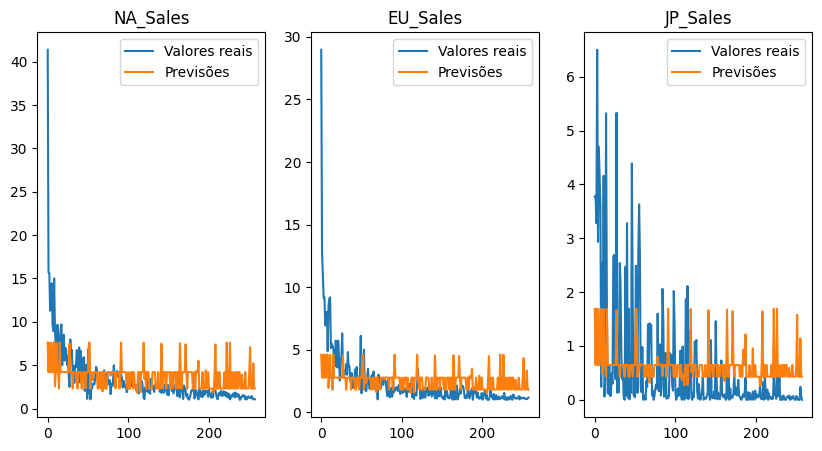

In [90]:
fig, ax = plt.subplots(1, 3, figsize=(10,5))
for i in range(3):
  ax[i].plot(vendas[:, i])
  ax[i].plot(previsoes[:, i])
  ax[i].legend(['Valores reais', 'Previsões'])
  ax[i].set_title(base.columns[4 + i])

In [96]:
# regressão com mais de um atributo